# Differential loops vs gene expression (Fig 4F,G)

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz'`  ·  _ref: gencode_
- `f'{indir}scRNA/{group}/{study}/{group}_{study}.h5ad'`  ·  _scRNA/expr_
- `f'{outdir}bulkexpr_{study}.hdf'`  ·  _expression_
- `f'{outdir}design_{study}.hdf'`  ·  _other_
- `f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf'`  ·  _other_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{loopdir}merged_loop.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_Q.hdf'`  ·  _loop calls_
- `f'{loopdir}loop_T.hdf'`  ·  _loop calls_
- `f'{indir}hg38.main.10kbin.TSS.slop2k.txt'`  ·  _other_
- `f'{cooldir}{ct}/{ct}.Q.cool'`  ·  _contacts (cool)_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [ ]:
from glob import glob

import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from scipy.stats import zscore

from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize

mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [ ]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [ ]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/loop_rna/'


In [ ]:
group = 'Breast'
study = 'Reed2024'


In [ ]:
gene_meta = pd.read_csv(f'{REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.flat.tsv.gz', sep='\t', header=0)
gene_meta['gene_id_idx'] = gene_meta['gene_id'].str.split('.').str[0]

In [ ]:
adata = anndata.read_h5ad(f'{indir}scRNA/{group}/{study}/{group}_{study}.h5ad')
adata

In [ ]:
adata.obs['celltype'] = adata.obs['level1'].astype(str)
adata.obs['celltype'] = adata.obs['celltype'].str.replace('_', '-').str.replace(' ', '-')

In [ ]:
leg = pd.Index(['Basal-myoepithelial', 'Luminal-adaptive-secretory-precurser', 'Luminal-hormone-sensing'])
legname = pd.Index(['BMYO', 'LASP', 'LHS'])
legmap = {xx:yy for xx,yy in zip(leg, legname)}


## celltype DEG, sex as replicates

In [ ]:
design = []
expr = []
for indiv in np.sort(adata.obs['donor_id'].unique()):
    for ct in leg:
        selc = (adata.obs['donor_id']==indiv) & (adata.obs['celltype']==ct)
        if selc.sum()>100:
            tmp = adata.raw.X[selc].sum(axis=0).A1
            expr.append(tmp)
            design.append([indiv, ct])
            
design = pd.DataFrame(design, columns=['donor_id', 'celltype'])
expr = pd.DataFrame(expr, columns=adata.raw.var.index)


In [ ]:
expr = expr.loc[:, expr.columns.isin(gene_meta['gene_id_idx'])]

In [ ]:
expr.to_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design.to_hdf(f'{outdir}design_{study}.hdf', key='data')


In [ ]:
expr = pd.read_hdf(f'{outdir}bulkexpr_{study}.hdf', key='data')
design= pd.read_hdf(f'{outdir}design_{study}.hdf', key='data')


In [ ]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

from statsmodels.stats.multitest import multipletests as FDR


In [ ]:
genes_to_keep = expr.columns[expr.sum(axis=0) >= 10]
counts_df = expr[genes_to_keep]
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=design,
    design_factors=['donor_id', 'celltype'],
    refit_cooks=True,
    inference=inference,
    # n_cpus=8, # n_cpus can be specified here or in the inference object
)
dds.deseq2()


In [ ]:
for i in range(len(leg)-1):
    for j in range(i+1, len(leg)):
        stat_res = DeseqStats(dds, contrast=['celltype', leg[i], leg[j]], inference=inference)
        stat_res.summary()
        deg_stats = stat_res.results_df.copy()
        # deg_stats = pd.read_hdf(f'{outdir}DEG_SCT_VCT_stats.hdf', key='data')
        deg_stats['pvalue'] = deg_stats['pvalue'].fillna(1)
        deg_stats['fdr'] = FDR(deg_stats['pvalue'], alpha=0.05, method='fdr_bh')[1]
        deg_stats.to_hdf(f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf', key='data')
        selc = (np.abs(deg_stats['log2FoldChange'])>1) & (deg_stats['fdr']<1e-5)
        print(leg[i], leg[j], selc.sum())


In [ ]:
for i in range(len(leg)-1):
    for j in range(i+1, len(leg)):
        deg_stats = pd.read_hdf(f'{outdir}DEG/DEG_{leg[i]}_{leg[j]}_stats.hdf', key='data')
        selc = (np.abs(deg_stats['log2FoldChange'])>2) & (deg_stats['fdr']<1e-10)
        print(leg[i], leg[j], selc.sum())
        if (i==0) and (j==1):
            selg = pd.Index(np.zeros(deg_stats.shape[0]))
        else:
            selg = selg | selc
            
print(selg.sum())


In [ ]:
exprtmp = expr / expr.sum(axis=1).values[:, None] * 1e6
exprtmp = exprtmp[deg_stats.index[selg]]
exprtmp.index = design['celltype'].astype(str) + '_' + design['donor_id'].astype(str)

In [ ]:
cg = sns.clustermap(zscore(exprtmp.T, axis=1), metric='cosine', cmap='Reds', vmin=0, vmax=2)


In [ ]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


## 3Ccluster diff loop

In [ ]:
res = 10000
L2_meta = pd.read_csv(f'{indir}subtype_meta.tsv', sep='\t', header=0, index_col=0)
L2_annot = L2_meta['celltype_L2_both_abbr'].to_dict()


In [ ]:
loopdir = f'{ENTEX_ROOT}/analysis/diff_loop/EpiBrst/'
loopall = pd.read_hdf(f'{loopdir}merged_loop.hdf', key='data')
loopq = pd.read_hdf(f'{loopdir}loop_Q.hdf', key='data')
loopt = pd.read_hdf(f'{loopdir}loop_T.hdf', key='data')


In [ ]:
from scipy.stats import norm, zscore

thres1 = norm.isf(0.025)
thres2 = norm.isf(0.15)
print(thres1, thres2)
fdrthres = 0.01


In [ ]:
statfilter = (zscore(np.log10(loopall['Qanova']))>thres2) & (zscore(np.log10(loopall['Tanova']))>thres2)
fdrfilter = (loopall['Qfdr']<fdrthres) & (loopall['Efdr']<fdrthres) & (loopall['Tfdr']<fdrthres)
selloop = statfilter # & fdrfilter
print(statfilter.sum(), fdrfilter.sum(), selloop.sum())


In [ ]:
diffloop = loopall.loc[selloop, [0,1,4]]
diffloop[[1, 4]] = diffloop[[1, 4]] // res
diffloop = diffloop.reset_index()
diffloop


In [ ]:
data = pd.read_csv(f'{indir}hg38.main.10kbin.TSS.slop2k.txt', sep='\t', header=None, index_col=None)
data[6] = data[6].str.split('.').str[0]
data[3] = data[0] + '-' + (data[1] // res).astype(str)
bin2gene = {xx:[] for xx in data[3].values}
data = data[data[6].isin(exprtmp.columns)]
for xx,yy in data[[3,6]].values:
    bin2gene[xx].append(yy)
    

In [ ]:
selloop = []
selgene = []
for loop in diffloop[[0, 1, 4, 'index']].values:
    xx = f'{loop[0]}-{loop[1]}'
    yy = f'{loop[0]}-{loop[2]}'
    zz = bin2gene[xx] + bin2gene[yy]
    if len(zz)>0:
        selloop.append(np.repeat([loop[3]], len(zz)))
        selgene.append(zz)

selloop = np.concatenate(selloop)
selgene = np.concatenate(selgene)
print(len(selloop), len(selgene))


In [ ]:
tmp3c = loopq.loc[selloop]
tmp3c = zscore(tmp3c, axis=1)

In [ ]:
tmprna = exprtmp.loc[:, selgene].T
tmprna = zscore(tmprna, axis=1)

In [ ]:
def order_row(data, nc):
    data = data.reset_index(drop=True)
    
    # Perform KMeans clustering    
    kmeans = KMeans(n_clusters=nc, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(data)

    # Create a new dataframe with cluster labels
    cluster_df = pd.DataFrame({'Cluster': clusters}, index=data.index)

    # Sort the data by cluster and plot the heatmap
    merged_data = pd.concat([data, cluster_df], axis=1).groupby(by='Cluster').mean()
    cg = sns.clustermap(merged_data, cmap='vlag', metric='cosine', figsize=(6,4))
    rorder = cg.dendrogram_row.reordered_ind.copy()
    corder = cg.dendrogram_col.reordered_ind.copy()
    
    leg = merged_data.index[rorder]
    count = pd.Series(clusters).value_counts().loc[leg]
    sorted_data = pd.concat([data[clusters==i] for i in leg], axis=0)
    
    return sorted_data, count, cluster_df, corder


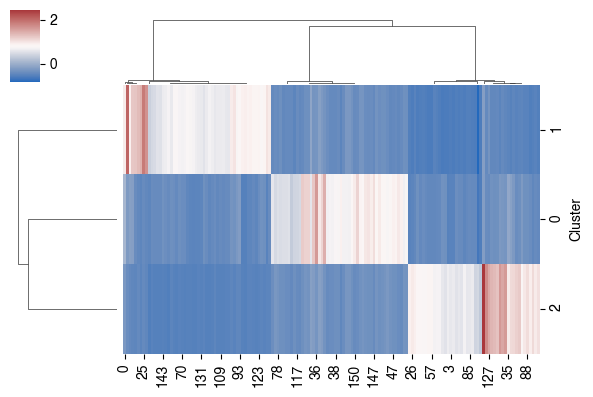

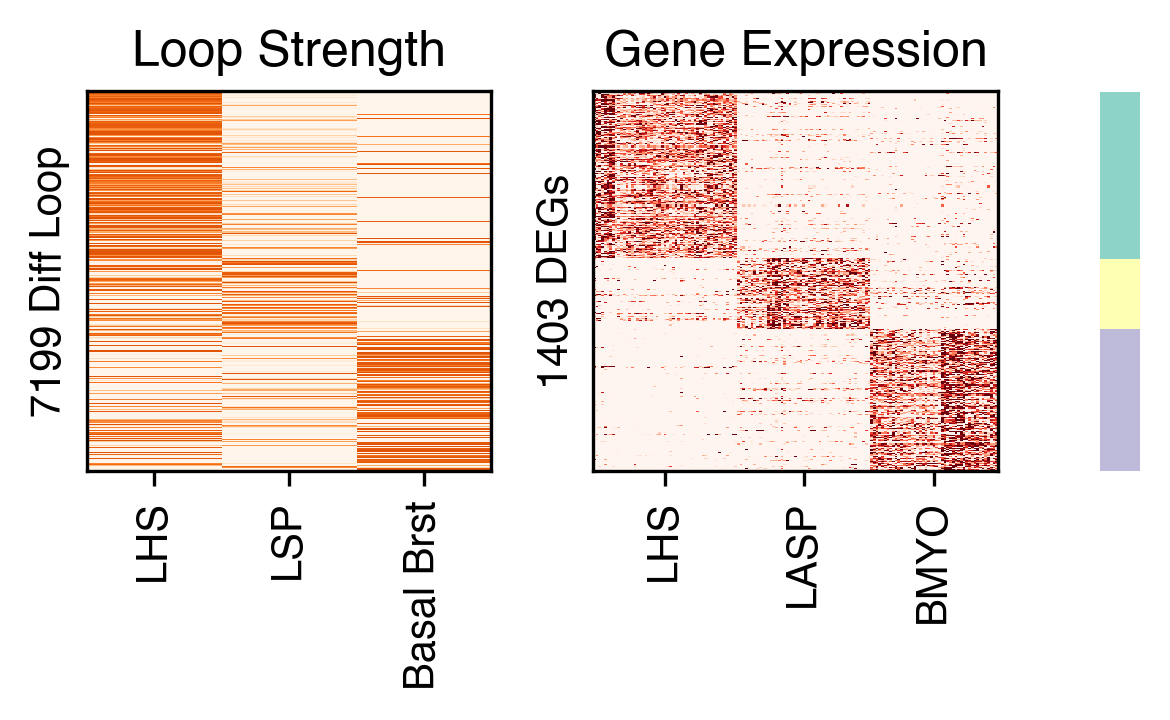

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.patches as patches

nc = 3
group_palette = sns.color_palette('Set3', nc)
tmp = np.concatenate([tmp3c.values, tmprna.values], axis=1)
tmp, count, label, corder = order_row(pd.DataFrame(tmp), nc=nc)
corder = pd.Index(corder)
corder_3c = corder[corder<len(leg)]
corder_rna = corder[corder>=len(leg)] - len(leg)

fig, axes = plt.subplots(1, 3, figsize=(4,2.5), dpi=300, sharey='all', 
                         gridspec_kw={'width_ratios': [10, 10, 1]})

ax = axes[0]
ax.imshow(tmp3c.iloc[tmp.index, corder_3c], cmap='Oranges', aspect='auto', 
          interpolation='none', rasterized=True, vmin=0, vmax=2)
ax.set_xticks(np.arange(tmp3c.shape[1]))
ax.set_xticklabels(tmp3c.columns[corder_3c].map(L2_annot), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selloop).shape[0]} Diff Loop')
ax.set_title('Loop Strength')

ax = axes[1]
ax.imshow(tmprna.iloc[tmp.index, corder_rna], cmap='Reds', aspect='auto', 
          vmin=0, vmax=2, interpolation='none', rasterized=True)
xticks = pd.Series(tmprna.columns[corder_rna].str.split('_').str[0]).reset_index().groupby(0)['index'].mean().sort_values()
ax.set_xticks(xticks)
ax.set_xticklabels(xticks.index.map(legmap), rotation=90)
ax.set_yticks([])
ax.set_ylabel(f'{np.unique(selgene).shape[0]} DEGs')
ax.set_title('Gene Expression')

ax = axes[2]
offset = [0] + list(count.cumsum())
ax.axis('off')
for k in range(nc):
    rect = patches.Rectangle((0, offset[k]), 1, offset[k+1]-offset[k], linewidth=0, 
                             edgecolor='none', facecolor=group_palette[k])
    ax.add_patch(rect)

fig.tight_layout()
fig.savefig(f'{outdir}EpiBrst_diffloop_deg_heatmap.pdf', transparent=True)

# ax.set_yticks(count.cumsum()-0.5)
# ax.set_yticklabels(count.index)


In [ ]:
leg = pd.Index(['c18-b0', 'c18-b1', 'c25-b0'])
cooldir = f'{indir}loop/subtype/'


In [ ]:
gtmp = 'OXTR'
lslop, rslop = 1000000, 1000000

chrom, start, end, strand = gene_meta.loc[gene_meta['gene_name']==gtmp, ['chrom', 'start', 'end', 'strand']].iloc[0]
if strand=='+':
    tss = start
else:
    tss = end

ll, rr = (tss - lslop), (tss + rslop)
print(chrom, ll, rr)


In [ ]:
resl = 10000
loopl, loopr = (ll//resl), (rr//resl)
print(loopl, loopr)

In [ ]:
## Load cell type Q

from scipy import ndimage as nd

dstall = []
for ct in leg:
    cool = cooler.Cooler(f'{cooldir}{ct}/{ct}.Q.cool')
    Q = cool.matrix(balance=False, sparse=True).fetch(chrom).tocsr()
    tmp = Q[loopl:loopr, loopl:loopr].toarray()
    dstall.append(tmp)
    print(ct)
    

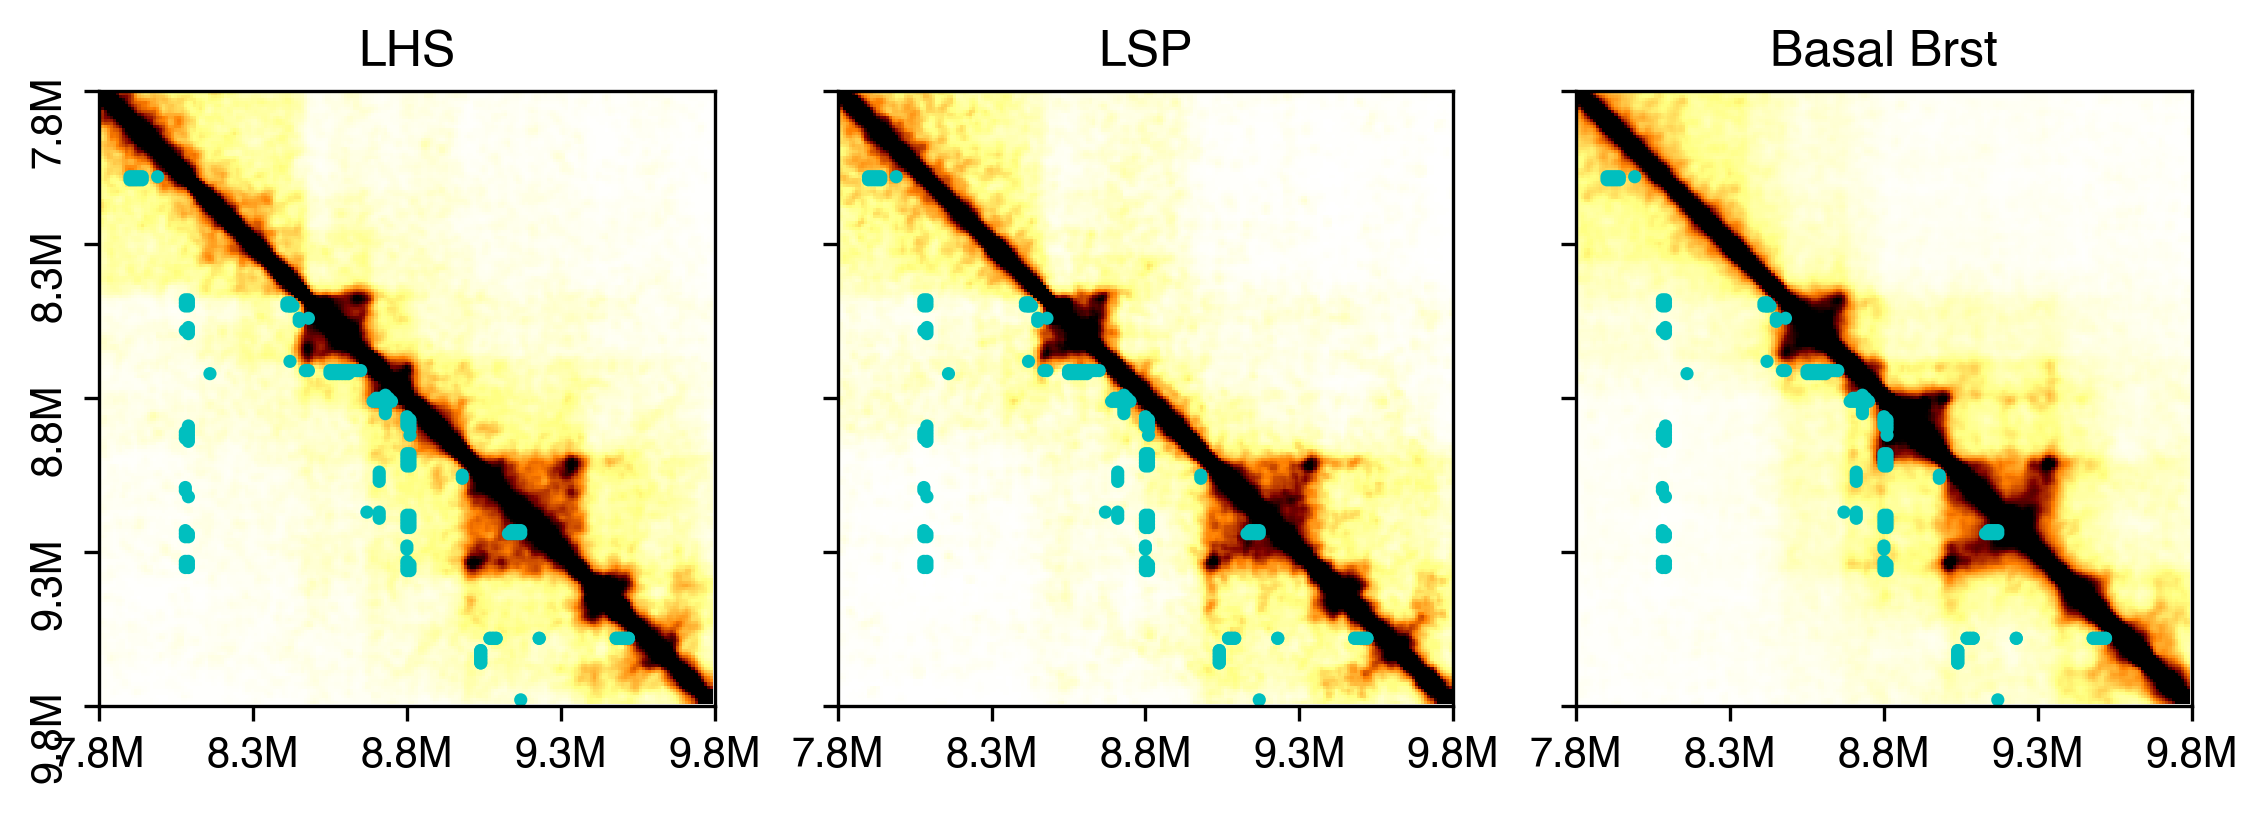

In [ ]:
fig, axes = plt.subplots(1, len(leg), figsize=(3*len(leg), 3), sharex='all', sharey='all', dpi=300)

## differential feature position at 10k resolution
tmpl = loopall.loc[selloop, [1,4]] // resl - loopl
tmpl = tmpl.loc[(tmpl[1]>0) & (tmpl[4]<(loopr-loopl))].values

for i in range(len(leg)):
    ax = axes[i]
    # ax.axis('equal')
    ax.set_title(leg.map(L2_annot)[i])
    img = ax.imshow(dstall[i], cmap='afmhot_r', vmin=0, vmax=0.012)
    ## plot diff loop
    ax.scatter(tmpl[:, 0], tmpl[:, 1], alpha=1, s=10, marker='o', edgecolors='none', color='c', rasterized=True)

    ax.set_xlim([0, loopr-loopl])
    ax.set_ylim([loopr-loopl, 0])
    step = (loopr-loopl)//4
    ticks = np.arange(0, loopr-loopl+1, step)
    ticklabels = [f'{np.around(xx*resl/1e6, decimals=1)}M' for xx in np.arange(loopl, loopr+1, step)]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(ticklabels, fontsize=10, rotation=90)

# fig.tight_layout()
fig.savefig(f'{outdir}diffloop_{gtmp}.pdf', transparent=True, dpi=300)
